### 1.4.9.1. Euler's Method

$$
y_{n+1} = y_n + h\,f(x_n, y_n), \qquad x_{n+1} = x_n + h .
$$

**Explanation:**

When an initial-value problem $y' = f(x,y)$, $y(x_0) = y_0$ has no closed-form solution, it can be approximated numerically. **Euler's method** takes a small step $h$ along the [direction field](../02_First_Order_Equations/01_direction_fields.ipynb): from the current point it follows the slope $f(x_n, y_n)$ — exactly the [linear (tangent-line) approximation](../../03_Calculus/02_Single_Variable_Differentiation/10_linear_approximation.ipynb) — to the next point. It is the simplest integrator and the conceptual basis of all the others, but only first-order accurate: the local truncation error is $O(h^2)$ and the global error $O(h)$, so halving $h$ roughly halves the error. It is the starting point for simulating dynamics in control and reinforcement-learning environments.

**Properties:**
- Local truncation error $O(h^2)$ per step; accumulated (global) error $O(h)$.
- The method just iterates the tangent-line step, so it tends to drift off curved solutions.

**Numerical Example:**

Approximate $y(1.5)$ for $y' = 2xy$, $y(1) = 1$ with $h = 0.1$ (exact solution $y = e^{x^2 - 1}$).

**Step 1** ($x_0 = 1$, $y_0 = 1$):

$$
y_1 = y_0 + h\,f(x_0, y_0) = 1 + 0.1\,(2\cdot 1\cdot 1) = 1.2, \qquad x_1 = 1.1 .
$$

**Step 2** ($x_1 = 1.1$, $y_1 = 1.2$):

$$
y_2 = 1.2 + 0.1\,(2\cdot 1.1\cdot 1.2) = 1.2 + 0.264 = 1.464, \qquad x_2 = 1.2 .
$$

Continuing to $x = 1.5$ gives $y_5 \approx 2.926$, while the exact value is $y(1.5) = e^{1.25} \approx 3.490$. Euler underestimates here because the solution is convex and the tangent steps fall below it — an error that shrinks as $h \to 0$.

In [1]:
import numpy as np

def euler(slope, x0, y0, step, target):
    xs, ys = [x0], [y0]
    while xs[-1] < target - 1e-9:
        ys.append(ys[-1] + step * slope(xs[-1], ys[-1]))
        xs.append(xs[-1] + step)
    return np.array(xs), np.array(ys)

slope = lambda x, y: 2 * x * y
grid, approximation = euler(slope, 1.0, 1.0, 0.1, 1.5)
exact = np.exp(grid**2 - 1)

for x_value, y_value, exact_value in zip(grid, approximation, exact):
    print(f"x={x_value:.1f}  Euler={y_value:.4f}  exact={exact_value:.4f}")
print("error at x=1.5:", abs(approximation[-1] - exact[-1]))

x=1.0  Euler=1.0000  exact=1.0000
x=1.1  Euler=1.2000  exact=1.2337
x=1.2  Euler=1.4640  exact=1.5527
x=1.3  Euler=1.8154  exact=1.9937
x=1.4  Euler=2.2874  exact=2.6117
x=1.5  Euler=2.9278  exact=3.4903
error at x=1.5: 0.562530349461845


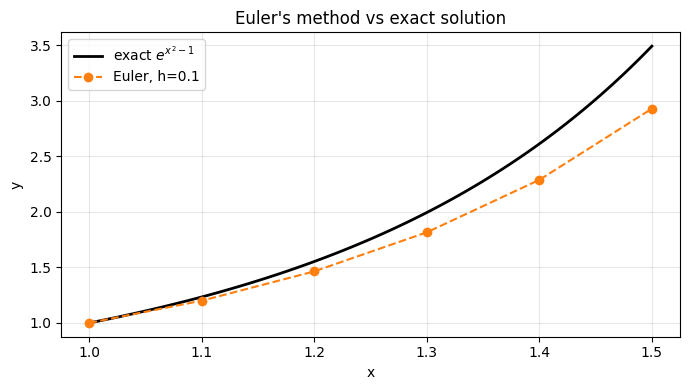

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fine = np.linspace(1, 1.5, 100)
plt.figure(figsize=(7, 4))
plt.plot(fine, np.exp(fine**2 - 1), "k", linewidth=2, label="exact $e^{x^2-1}$")
plt.plot(grid, approximation, "o--", color="C1", label="Euler, h=0.1")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Euler's method vs exact solution")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Matrix Exponential](../08_Systems_of_Linear_First_Order_ODEs/04_matrix_exponential.ipynb) | [Next: Runge-Kutta Methods ➡️](./02_runge_kutta_methods.ipynb)